# 04 — Paper figures

Create additional paper-oriented figures manually. The pipeline already writes default heatmaps and timelines.

C:\Users\gianl\Documents\Code\RobustEdgeBench\src\robustedge\plotting.py:60: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots(figsize=(4.6, 3.0))


Wrote manual heatmaps to ..\outputs\notebook_pipeline\figures_manual


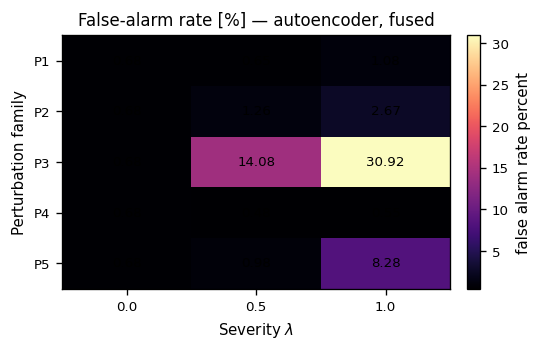

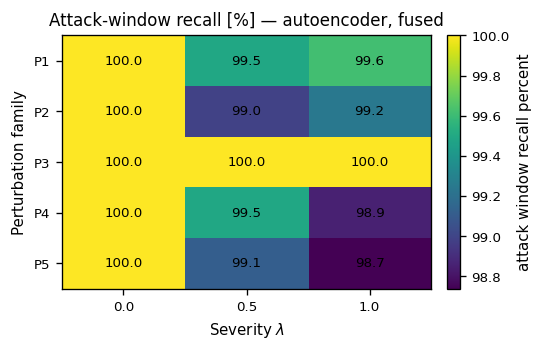

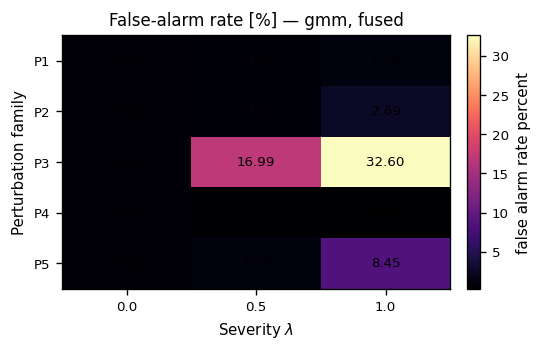

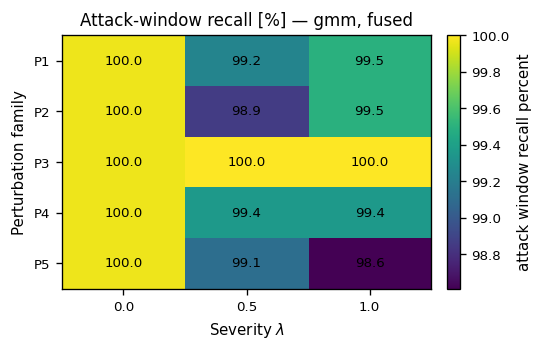

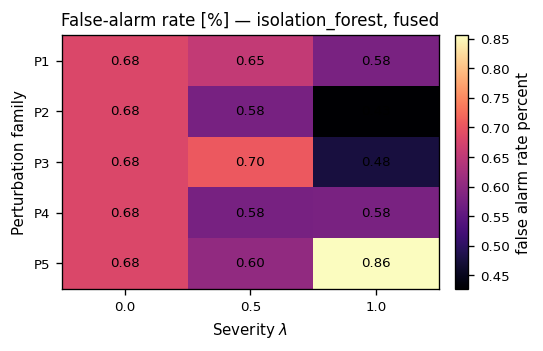

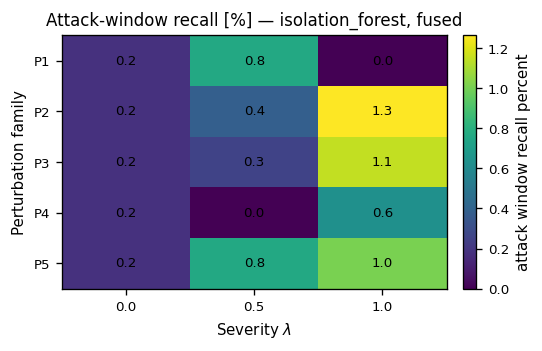

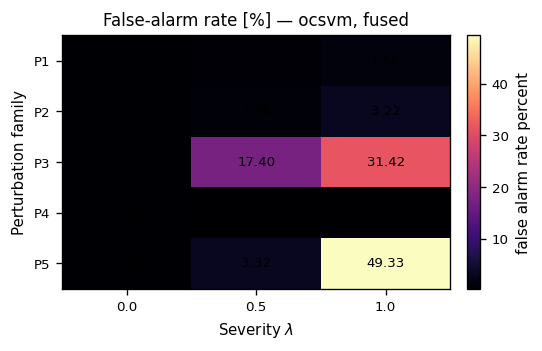

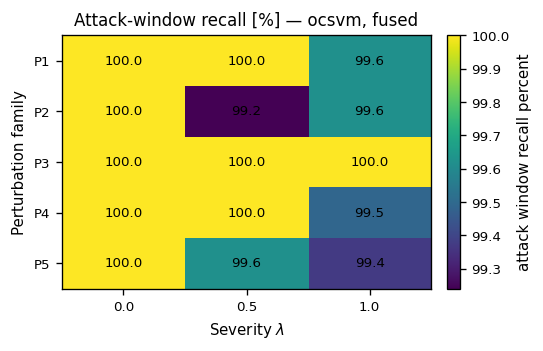

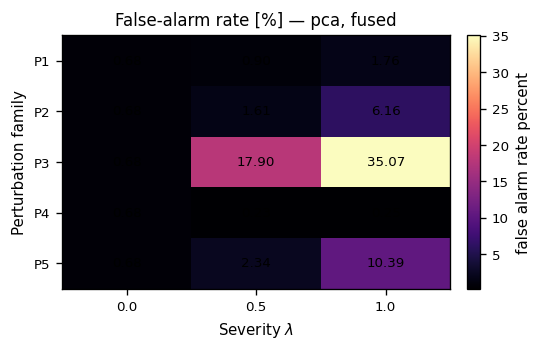

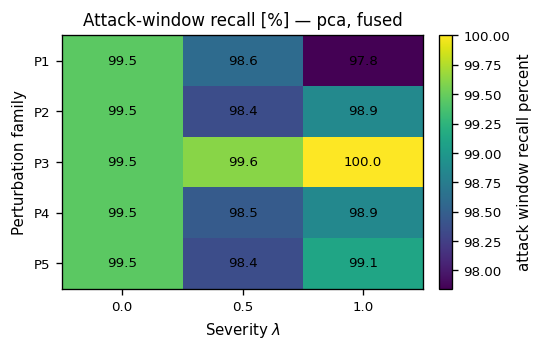

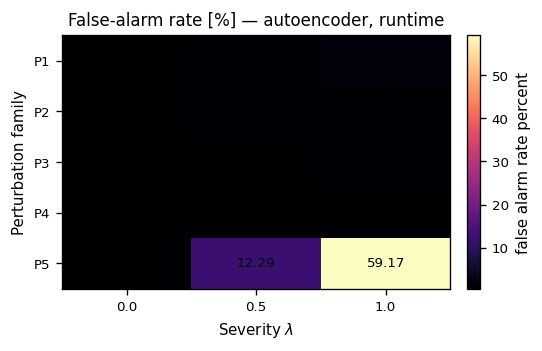

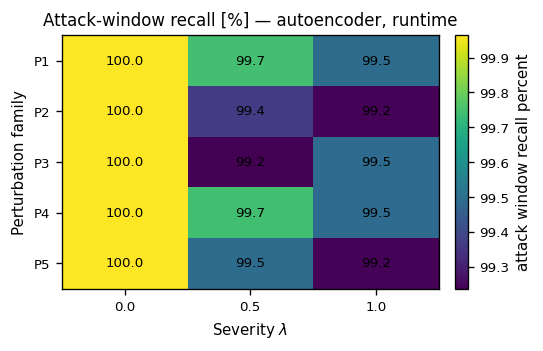

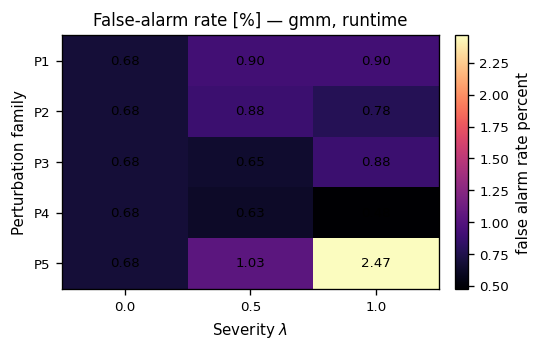

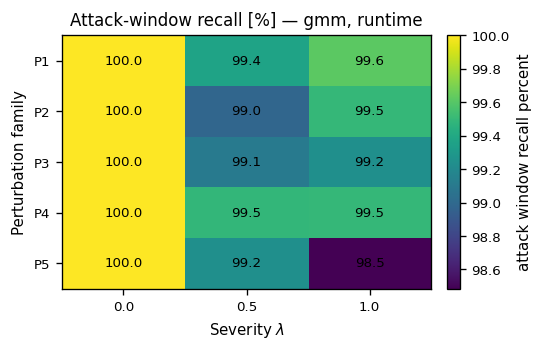

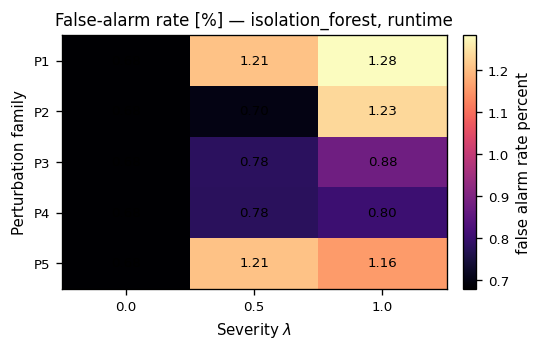

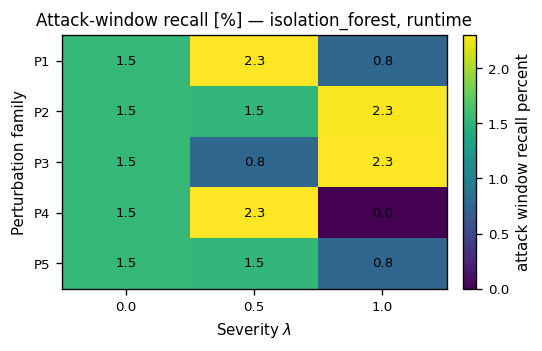

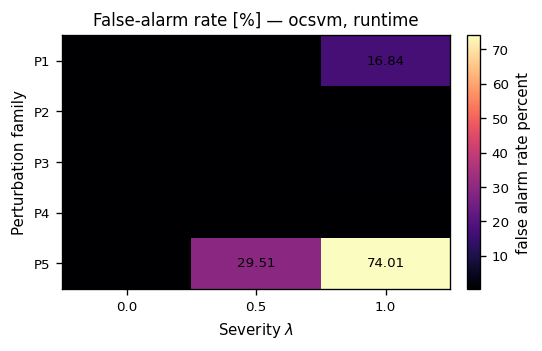

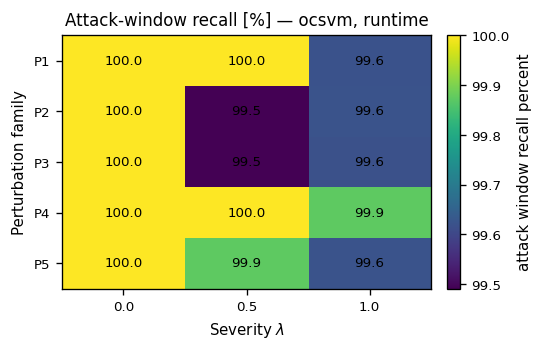

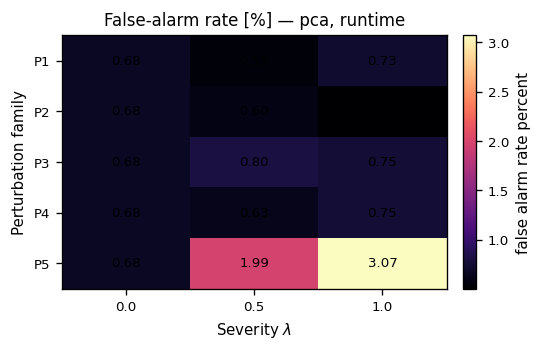

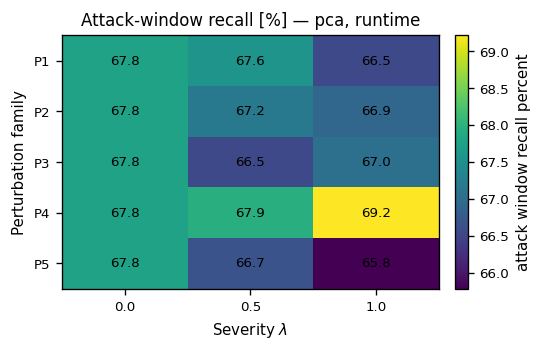

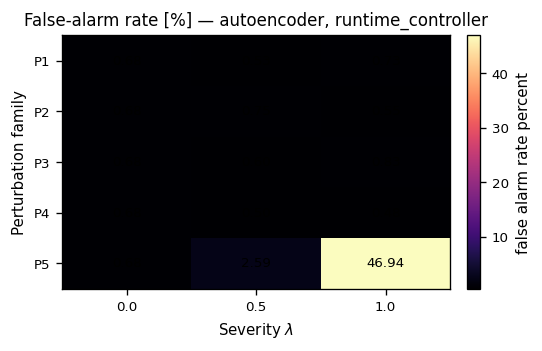

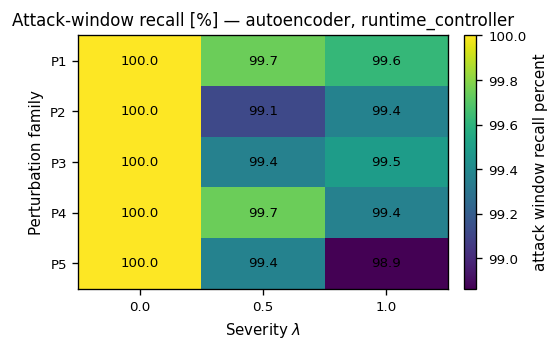

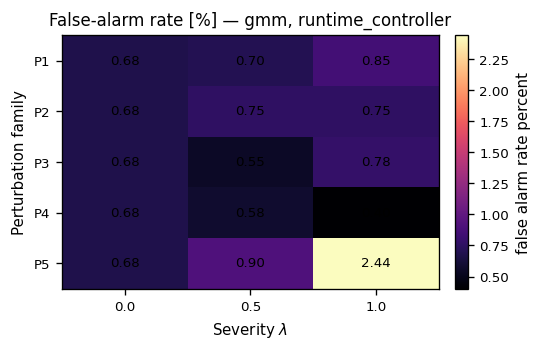

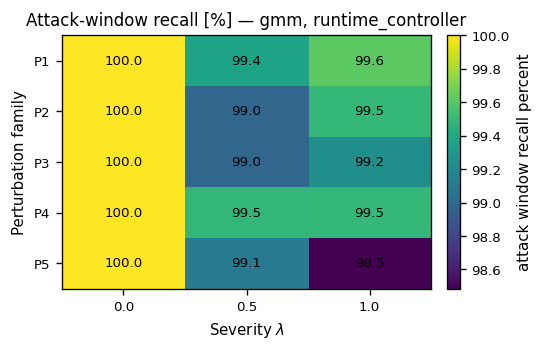

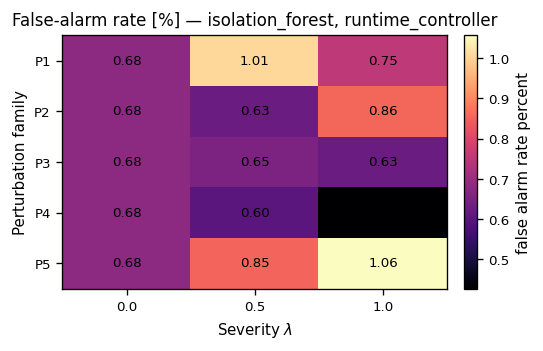

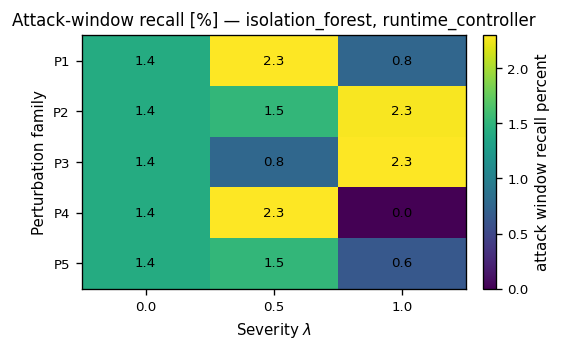

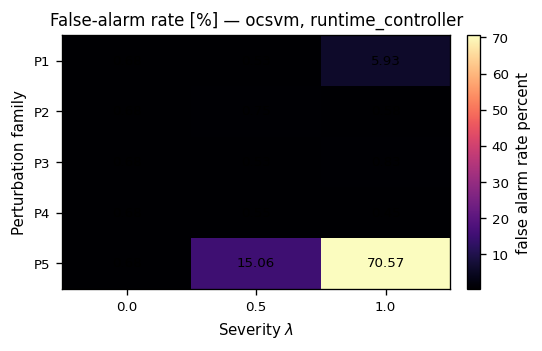

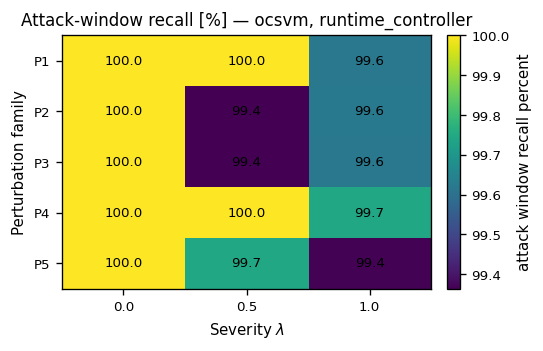

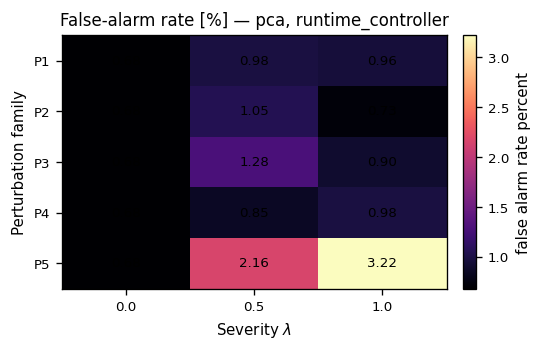

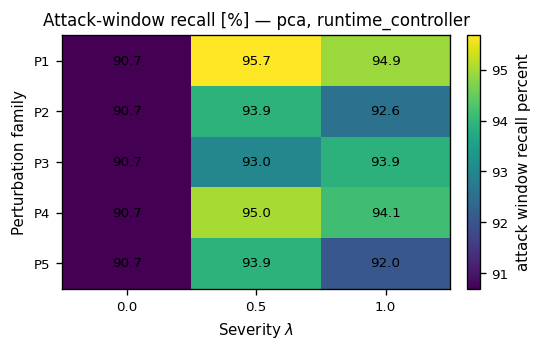

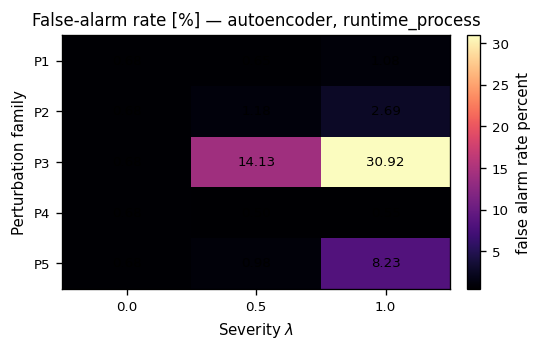

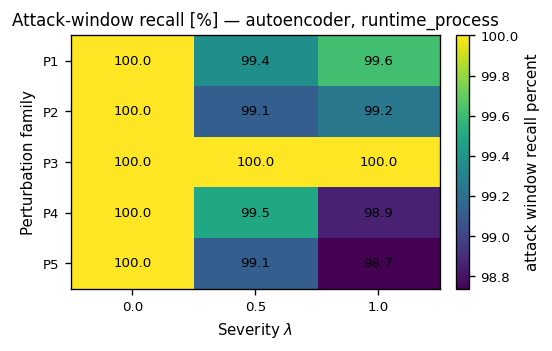

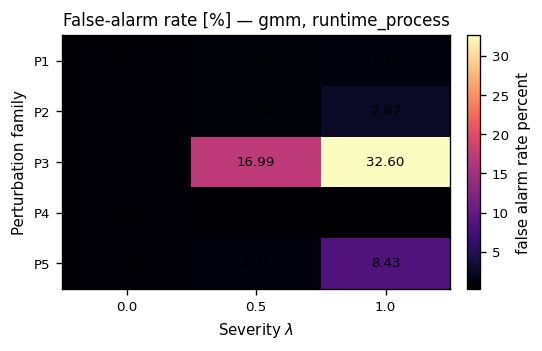

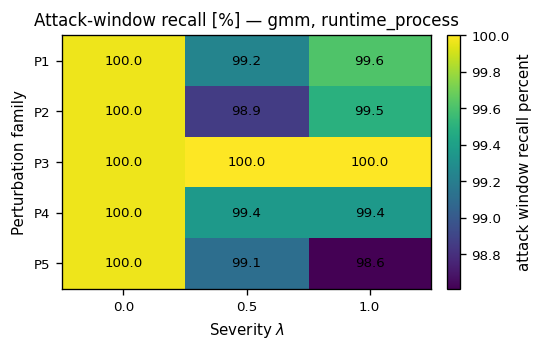

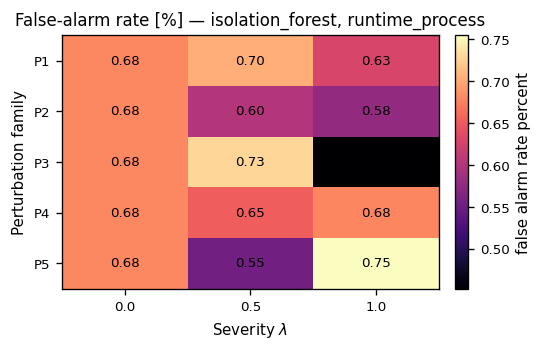

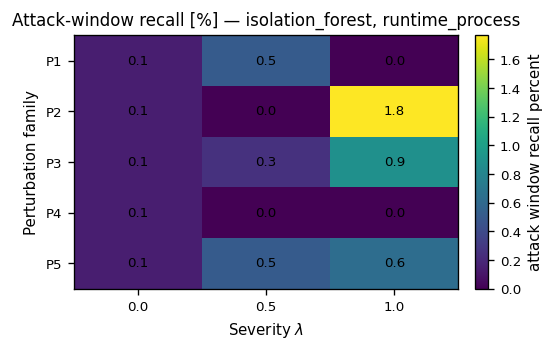

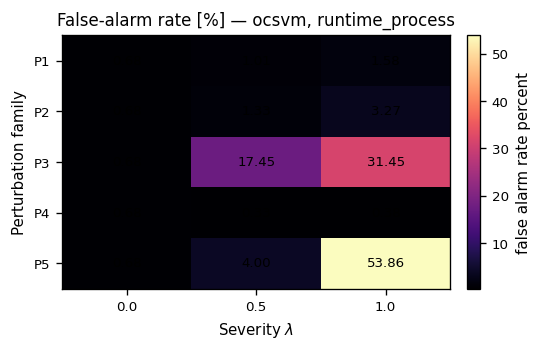

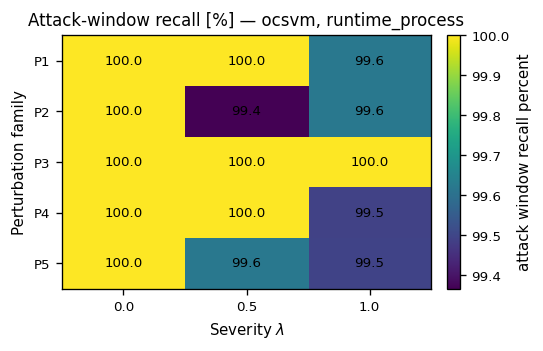

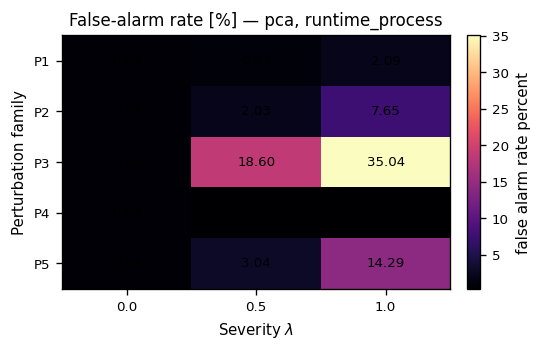

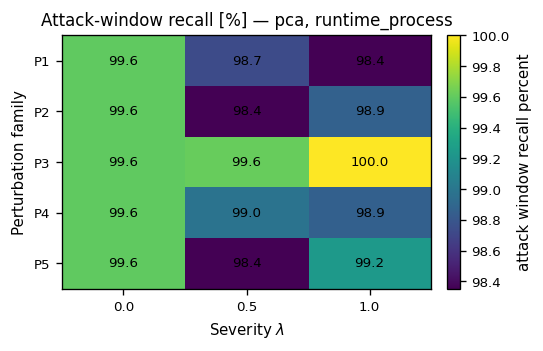

In [1]:
from pathlib import Path
import pandas as pd
from robustedge.plotting import plot_metric_heatmap, plot_metric_distribution, plot_all_models_timeline
from robustedge.robustness import add_lambda0_baseline

OUTPUT_DIR = Path('../outputs/notebook_pipeline')
FIG_DIR = OUTPUT_DIR / 'figures_manual'
FIG_DIR.mkdir(parents=True, exist_ok=True)

metrics = pd.read_csv(OUTPUT_DIR / 'metrics_by_run.csv')
window_pooled = pd.read_csv(OUTPUT_DIR / 'metrics_window_pooled_all_attacks.csv')
scores = pd.read_csv(OUTPUT_DIR / 'scores_by_window.csv')

benign = add_lambda0_baseline(window_pooled, benign=True)
attack = add_lambda0_baseline(window_pooled, benign=False)

for feature_view in sorted(scores.feature_view.unique()):
    for detector in sorted(scores.detector.unique()):
        plot_metric_heatmap(
            benign[benign.phase.isin(['phase1_clean_benign','phase3_perturbed_benign'])],
            metric_col='false_alarm_rate_percent',
            detector=detector,
            feature_view=feature_view,
            output_path=FIG_DIR / 'manual_fa_heatmaps' / f'{feature_view}_{detector}.png',
            title=f'False-alarm rate [%] — {detector}, {feature_view}',
            value_format='.2f',
            cmap='magma',
        )
        plot_metric_heatmap(
            attack[attack.phase.isin(['phase2_clean_attacked','phase4_perturbed_attacked'])],
            metric_col='attack_window_recall_percent',
            detector=detector,
            feature_view=feature_view,
            output_path=FIG_DIR / 'manual_attack_recall_heatmaps' / f'{feature_view}_{detector}.png',
            title=f'Attack-window recall [%] — {detector}, {feature_view}',
            value_format='.1f',
            cmap='viridis',
        )
print(f'Wrote manual heatmaps to {FIG_DIR}')

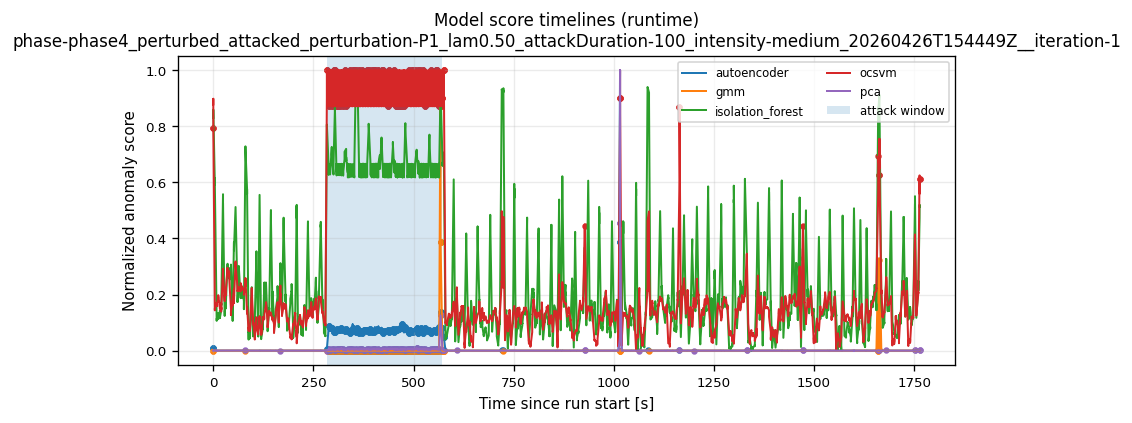

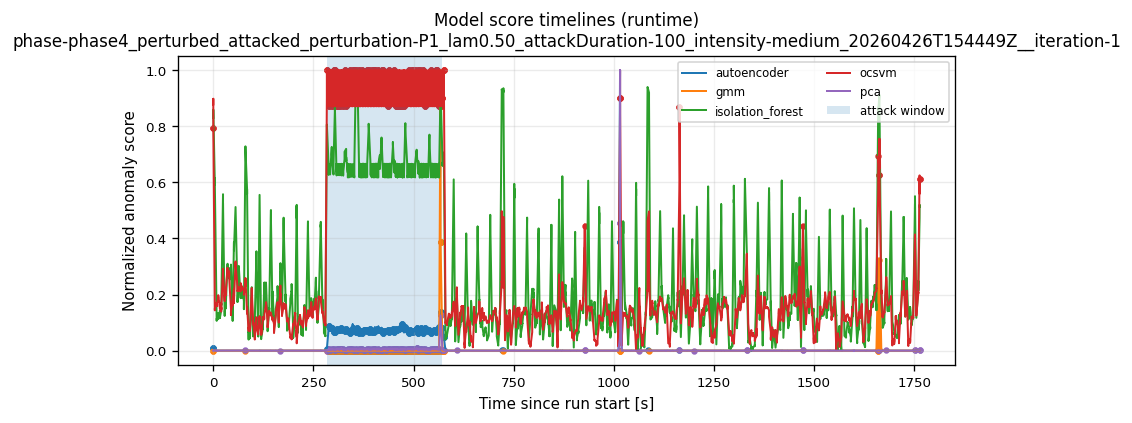

In [2]:
# Example all-model timeline for one run and one feature view
run_id = scores[scores.phase == 'phase4_perturbed_attacked'].run_id.iloc[0]
feature_view = scores.feature_view.iloc[0]
plot_all_models_timeline(scores, run_id=run_id, feature_view=feature_view, output_path=FIG_DIR / 'example_all_models_timeline.png')